#### A Neural Probabilistic Language Model

the aim of this notebook is to reproduce the architecture of the Neural Probabilistic model along the lines of "Bengio et al 2003"; the implementation is done in low-level PyTorch so as for abstraction and better viewer understanding.

This paper was a breakthrough in the field of ML and progressively AI as well, as it marked the approach of using n-dimensional vectors to represent the words and thus train the model on those n-dimensional vectors with meaningful features so as to assign some probability to unseen data as well, which was not something achieved solely through the n-gram models without smoothing techniques.

From my personal point of view as someone who has worked with both the ngram models and the NPLM[the abbreviation for Neural Probablistic Language Model] , i can say that the smoothening techniques were not the model learning from the datapoints but mere mathermatical manipulation to assign some standardised predictable probability to unseen datapoints however through NPLM, it could not be classified as a mathematical manipulation but the model learning and predicting the probability.

The code implements the architecture in the order represented by this picture, which gives the crux of the entire paper

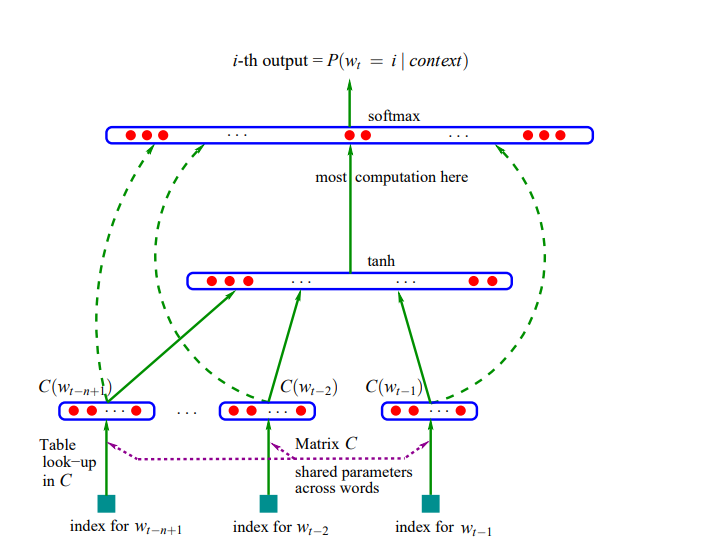

for the paper discussion and the implementation problems one may face I  would highly recommend reading my blogpost whose link would be somewhere in the readme.md 


##### All the imports here ↓

In [1]:
import os 
os.environ['KMP_DUPLICATE_LIB_OK'] = "TRUE" #this was a workaround to make torch import and run on my computer
import torch
import matplotlib.pyplot as plt
import torch.nn.functional as F 

#### Dividing the dataset into usable datapoints for the model training and testing

In [2]:
file = open("input.txt" , 'r')
content = file.read()
sentences = content.splitlines()

all_words = []

for sentence in sentences:
    words = sentence.split()
    all_words.extend(words)

unique_words = sorted(list(set(all_words)))

##### Creating an STOI and ITOS mapping so that it is easier to break the words into numerical indices which could be further represented by n-dimensional vectors

In [3]:
#creating the mapping 
stoi = {s:i+1 for i , s in enumerate(unique_words)}
stoi["."] = 0#this is the special starting token marking the start and the end 
itos ={i:s for s, i in stoi.items()}
vocab_size = len(itos)
vocab_size

25671

##### Dividing the dataset into train test and split with inhouse function made in raw python because i am trying to minimise my usage of any external library until needed- the data is being divided on the philosophy: 
80% data = train data

10% = validation data

10% = test data

In [4]:
##the model hyperparameters
window_size = 10
seed = 3801

In [5]:
def build_dataset(sentences):
    X , Y=  [] , []
    context_window = window_size

    for sentence in sentences:
        words =sentence.split()
        context=  [0]*context_window

        for word in words+["."]:
            ix = stoi[word]
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]
            #yes - it has rolling context ie 1 ,2 , 3 - > 4; 2 ,3 , 4-> 5----> this NPLM model is also  an  n gram in its core but just with embeddings
            # and way larger and alterable context


    X = torch.tensor(X)
    Y = torch.tensor(Y)

    print(X.shape , Y.shape)
    return X , Y 


In [6]:
#the division philosophy - mentioned above
train_percent = 0.8
val_percent = 0.1 
test_percent = 0.1#this is the remaining - one we can say as showed below


In [7]:
import random 
random.seed(seed)
random.shuffle(sentences)

n1 = int(train_percent*(len(sentences)))
n2= int((train_percent+val_percent)*(len(sentences)))

Xtr , Ytr = build_dataset(sentences[:n1])
Xval , Yval = build_dataset(sentences[n1:n2])
Xtest , Ytest = build_dataset(sentences[n2:])

torch.Size([194521, 10]) torch.Size([194521])
torch.Size([24075, 10]) torch.Size([24075])
torch.Size([24055, 10]) torch.Size([24055])


##### Here are the parameters which would be used in the model - the first cell is just setting up the constants and then the next ones are the parameters ; used torch because of the GPU support :))

In [8]:
#helper variables for the parameters  
embeddings = 100
hidden_neuron  = 200
g = torch.Generator().manual_seed(seed)


In [9]:
#parameters 
C = torch.randn((vocab_size , embeddings) ,generator  =g)
W1 = torch.randn((embeddings*window_size , hidden_neuron) , generator = g)*0.01
b1 = torch.randn((hidden_neuron) ,  generator = g)
W2 = torch.randn((hidden_neuron , vocab_size) , generator = g)*0.001
b2 = torch.randn((vocab_size) , generator = g)*1

parameters = [C , W1 , W2 , b1 , b2]
sum(p.nelement() for p in parameters)

for p in parameters:
    p.requires_grad = True

##### from here on uptil the sampling this is all training and this would include 
1) setting up thehe constants
2) training and then testing the loss
3) for verifying after the training i am testing the loss on the train and the val data - to check if it overfit or underfit

for finding the learning rate i used the learning rate sweep which you can find in the optimal_lr.ipynb - notebook

In [10]:
#these are the variables for the training purposes
max_steps = 10000
batch_size = 200 

#### this is the forward pass and training 
so in this algorithm , I am implementing the training mechanism on small batch sizes so as for better performances and less compute on the CPU
and then repeatidly storing the loss in an array so as to plot relations with the loss in my future uses 


In [12]:
lossi = []#appending the losses in this list so as to analyse how this decreases with i 
step= []
for i in range(max_steps):
    #the minibatch construction
    ix = torch.randint(0 , Xtr.shape[0] , (batch_size , ) , generator = g )
    Xb , Yb = Xtr[ix] , Ytr[ix]

    #implementing the forward pass
    emb = C[Xb]
    embcat = emb.view(batch_size , window_size*embeddings)
    h = torch.tanh(embcat@W1 + b1)
    logits = h@W2+b2 
    loss = F.cross_entropy(logits , Yb)
    perplexity = loss.exp()


    #implementing the backward pass 
    for p in parameters:
        p.grad = None
    loss.backward()

    lr = 0.1#found through learning rate sweep ; in the optimal_lr.ipynb
    for p in parameters:
        p.data += -lr*p.grad
    lossi.append(loss.item())
    step.append(i)

    if i%1000==0:
        print(i)
    

print(loss.item())
print(perplexity.item())

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
6.1389617919921875
463.5720520019531


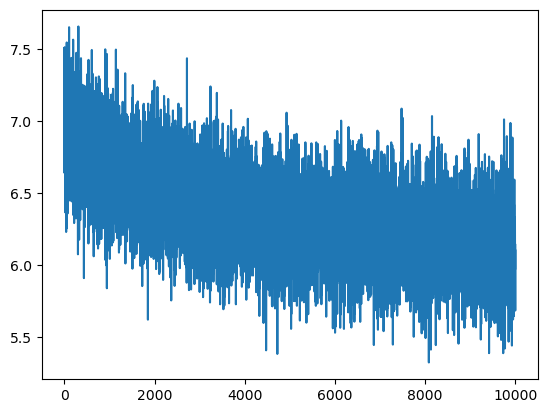

In [13]:
plt.plot(step , lossi)
plt.show()


In [15]:
@torch.no_grad()#this decorator disables gradient tracking 
def split_loss(split):
    x , y = {

    'train' : (Xtr , Ytr) ,
    'val': (Xval , Yval),
    'test' : (Xtest , Ytest),
        
    }[split]
    batch_size = 200
    ix = torch.randint(0 , x.shape[0] ,(batch_size ,) ,  generator = g )
    Xb , Yb = x[ix] , y[ix]
    emb = C[Xb]
    embcat = emb.view(emb.shape[0], -1)
    h = torch.tanh(embcat@W1 + b1)
    logits = h@W2+b2 
    loss = F.cross_entropy(logits , y[ix])
    perplexity = loss.exp()
    print(split , loss.item() , perplexity.item())


split_loss('train')
split_loss('val')

train 6.109906196594238 450.2964782714844
val 6.198848247528076 492.1818542480469


In [16]:
split_loss("test")#this is the final loss

test 6.1270670890808105 458.0906677246094


#### Sampling from the model

In [17]:
#sample from the model
g  = torch.Generator().manual_seed(seed)


for _ in range(5):
    out = []
    context_window =  10
    context = [0]*context_window

    while True:
        emb = C[torch.tensor([context])]
        embcat = emb.view( 1,-1)
        h = torch.tanh(embcat@W1 + b1)
        logits = h@W2+b2 
        probs = F.softmax(logits , dim  = 1)
        ix = torch.multinomial(probs , num_samples = 1 ,  generator = g).item()
        context = context[1:]+[ix]
        out.append(ix)
        if ix == 0 :
            break 

    print(" ".join(itos[i] for i in out))

        

CLARENCE: .
First VINCENTIO: .
Or art charity Sith Proclaimed Tying for to hear .
.
What's made for no of on to be me. .
